In [1]:
import numpy as np
import pandas as pd
import bisect
import matplotlib.pyplot as plt

In [2]:
class EventData:
    def __init__(self, time, energy, x, y, z, MC):
        self.time = time
        self.energy = energy
        self.x = x
        self.y = y
        self.z = z
        self.MC = MC


In [4]:
def read_file(file_path):
    # Read the file into a pandas DataFrame
    df = pd.read_csv(file_path, delimiter=',', header=None)

    # Extract columns from the DataFrame
    time = df.iloc[:, 0]
    events = df.iloc[:, 1]
    x_coor = df.iloc[:, 2]
    y_coor = df.iloc[:, 3]
    z_coor = df.iloc[:, 4]
    MC = df.iloc[:, -1]

    # Convert events to energy
    energy = events / 280

    # Create list of EventData objects
    event_data = [EventData(t, e, x, y, z, mc) for t, e, x, y, z, mc in zip(time, energy, x_coor, y_coor, z_coor, MC)]

    return event_data

# Example usage
file_path = "../data_preprocessing/osiris_toydata_7.csv"
event_data = read_file(file_path)

In [5]:
def energy_cut(event_data, bi_range, po_range):
    bi_min, bi_max = bi_range
    po_min, po_max = po_range

    bi_events = []
    po_events = []

    # Separate events based on energy range and create EventData objects for Bi events
    for event in event_data:
        if bi_min <= event.energy <= bi_max:
            bi_events.append(EventData(time=event.time, energy=event.energy, x=event.x, y=event.y, z=event.z, MC=event.MC))

    # Separate events based on energy range and create EventData objects for Po events
    for event in event_data:
        if po_min <= event.energy <= po_max:
            po_events.append(EventData(time=event.time, energy=event.energy, x=event.x, y=event.y, z=event.z, MC=event.MC))

    return bi_events, po_events

In [6]:
def fv_cut(event_data, r_cut, z_cut):
    # Apply fiducial volume cut
    filtered_events = []

    for event in event_data:
        r = np.sqrt(event.x**2 + event.y**2)
        if r <= r_cut and event.z <= z_cut:
            filtered_events.append(EventData(time=event.time, energy=event.energy, x=event.x, y=event.y, z=event.z, MC=event.MC))


    return filtered_events

In [7]:
def binary_search(arr, target, key=lambda x: x):
    left, right = 0, len(arr)
    while left < right:
        mid = (left + right) // 2
        if key(arr[mid]) < target:
            left = mid + 1
        else:
            right = mid
    return left

def time_cut(bi_fv, po_fv, time_range):
    # Sort po_fv based on time
    po_fv_sorted = sorted(po_fv, key=lambda event: event.time)

    # Collect the filtered events
    bi_events_tc = []
    po_events_tc = []

    # Iterate through each bi_event
    for bi_event in bi_fv:
        # Calculate the time range for po_event lookup
        min_time_diff = bi_event.time + time_range[0]
        max_time_diff = bi_event.time + time_range[1]

        # Find the index range in po_fv_sorted where po_event.time falls within the specified range
        po_index_min = binary_search(po_fv_sorted, min_time_diff, key=lambda event: event.time)
        po_index_max = binary_search(po_fv_sorted, max_time_diff, key=lambda event: event.time)

        # Iterate over potential corresponding po_events
        for po_event in po_fv_sorted[po_index_min:po_index_max]:
            time_diff = po_event.time - bi_event.time

            # Check if time difference falls within the specified range
            if time_range[0] <= time_diff <= time_range[1]:
                # Append corresponding bi_event and po_event to filtered lists
                bi_events_tc.append(EventData(time=bi_event.time, energy=bi_event.energy, x=bi_event.x, y=bi_event.y, z=bi_event.z, MC=bi_event.MC))
                po_events_tc.append(EventData(time=po_event.time, energy=po_event.energy, x=po_event.x, y=po_event.y, z=po_event.z, MC=po_event.MC))

    return bi_events_tc, po_events_tc


In [16]:
from scipy.spatial import cKDTree

def distance_cut(bi_events_tc, po_events_tc, distance_threshold, time_range):
    # Sort po_events_tc by time
    po_events_sorted = sorted(po_events_tc, key=lambda event: event.time)

    # Collect the filtered events
    bi_events_dc = []
    po_events_dc = []

    # Build a k-d tree for spatial searching of po_events
    po_positions = np.array([(po_event.x, po_event.y, po_event.z) for po_event in po_events_sorted])
    tree = cKDTree(po_positions)

    # Iterate over each bi_event
    for bi_event in bi_events_tc:
        # Calculate the time range for po_event lookup
        min_time_diff = bi_event.time + time_range[0]
        max_time_diff = bi_event.time + time_range[1]

        # Find the index range in po_events_sorted where po_event.time falls within the specified range
        po_index_min = binary_search(po_events_sorted, min_time_diff, key=lambda event: event.time)
        po_index_max = binary_search(po_events_sorted, max_time_diff, key=lambda event: event.time)

        # Iterate over the potential corresponding po_events
        for po_event in po_events_sorted[po_index_min:po_index_max]:
            time_diff = po_event.time - bi_event.time

            # Check if time difference falls within the specified range
            if time_range[0] <= time_diff <= time_range[1]:
                # Perform spatial search using k-d tree for efficient nearest-neighbor lookup
                distance = tree.query([(bi_event.x, bi_event.y, bi_event.z)], k=1)[0][0]

                # If the distance is less than the threshold, add it to the results
                if distance < distance_threshold:
                    bi_events_dc.append(EventData(time=bi_event.time, energy=bi_event.energy, x=bi_event.x, y=bi_event.y, z=bi_event.z, MC=bi_event.MC))
                    po_events_dc.append(EventData(time=po_event.time, energy=po_event.energy, x=po_event.x, y=po_event.y, z=po_event.z, MC=po_event.MC))

    return bi_events_dc, po_events_dc


In [9]:
def count_MC(event_data):
    # Initialize counters for different MC values
    count_of_zeros = 0
    count_of_ones = 0
    count_of_twos = 0
    count_of_threes = 0
    count_of_fours = 0
    count_of_fives = 0

    # Iterate through event_data and count occurrences of different MC values
    for event in event_data:
        if event.MC == 0:
            count_of_zeros += 1
        elif event.MC == 1:
            count_of_ones += 1
        elif event.MC == 2:
            count_of_twos += 1
        elif event.MC == 3:
            count_of_threes += 1
        elif event.MC == 4:
            count_of_fours += 1
        elif event.MC == 5:
            count_of_fives += 1

    # Print the results
    print(f"Internal background: {count_of_zeros}")
    print(f"214 Bi Events: {count_of_ones}")
    print(f"214 Po events: {count_of_twos}")
    print(f"External background: {count_of_threes}")
    print(f"212 Bi events: {count_of_fours}")
    print(f"212 Po events: {count_of_fives}")


In [26]:
def calculate_time_differences_for_plot(bi_events, po_events):
    """
    Function to calculate the time differences between corresponding bi_events and po_events.
    
    Arguments:
    bi_events : list of EventData objects representing BiPo214 events.
    po_events : list of EventData objects representing BiPo212 events.
    
    Returns:
    time_diffs : list of time differences between corresponding bi_event and po_event times.
    """
    # Ensure both lists have the same length
    min_len = min(len(bi_events), len(po_events))  # Take the smaller length to avoid IndexError
    
    time_diffs = []
    
    # Iterate through both lists and calculate time differences for corresponding events
    for i in range(min_len):
        bi_event = bi_events[i]
        po_event = po_events[i]
        
        # Calculate the absolute time difference for corresponding events
        time_diff = abs(bi_event.time - po_event.time)
        time_diffs.append(time_diff)
    
    return time_diffs

In [44]:
# Function to plot histograms for time differences (Decay Curve)
def plot_histogram(time_diff, title, filename, color, x_limits=None, y_limits=None):
    plt.figure(figsize=(10, 5))
    plt.hist(time_diff, bins=100, color=color, alpha=0.7)
    plt.xlabel('Time Differences (seconds)')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.grid(True)
    if x_limits is not None:
        plt.xlim(x_limits)
    if y_limits is not None:
        plt.ylim(y_limits)
    plt.savefig(filename)
    plt.show()

In [28]:
# Function to plot energy spectrum
def plot_energy_spectrum(events, event_type, filename, color='blue'):
    energies = [event.energy for event in events]
    plt.figure(figsize=(10, 5))
    plt.hist(energies, bins=100, color=color, alpha=0.7)
    plt.xlabel('Energy (MeV)')
    plt.ylabel('Frequency')
    plt.title(f'Energy Spectrum for {event_type} Events')
    plt.grid(True)
    plt.savefig(filename)
    plt.show()

In [68]:
def calculate_metrics(event_data, bi_cut_214, po_cut_214, bi212_cut, po212_cut):
    # Initialize counters in dictionaries for each event type
    counts = {
        'bi214': {'TP': 0, 'FP_internal': 0, 'FP_external': 0, 'total': 0},
        'po214': {'TP': 0, 'FP_internal': 0, 'FP_external': 0, 'total': 0},
        'bi212': {'TP': 0, 'FP_internal': 0, 'FP_external': 0, 'total': 0},
        'po212': {'TP': 0, 'FP_internal': 0, 'FP_external': 0, 'total': 0},
    }
    
    # Map MC values to event types
    mc_to_event = {1: 'bi214', 2: 'po214', 4: 'bi212', 5: 'po212'}

    # Loop through the event data to classify and count each event
    for event in event_data:
        event_type = mc_to_event.get(event.MC)

        # Only process valid event types (1, 2, 4, 5)
        if event_type:
            counts[event_type]['total'] += 1
            
            # Check if the event is in the corresponding cut
            if event_type == 'bi214' and event in bi_cut_214:
                counts['bi214']['TP'] += 1
            elif event_type == 'po214' and event in po_cut_214:
                counts['po214']['TP'] += 1
            elif event_type == 'bi212' and event in bi212_cut:
                counts['bi212']['TP'] += 1
            elif event_type == 'po212' and event in po212_cut:
                counts['po212']['TP'] += 1
            
            # Update FP counts based on event MC values
            if event.MC == 0:  # False positive internal
                counts[event_type]['FP_internal'] += 1
            elif event.MC == 3:  # False positive external
                counts[event_type]['FP_external'] += 1

    # Helper function to calculate percentages
    def calculate_percentage(numerator, denominator):
        return (numerator / denominator) * 100 if denominator > 0 else 0

    # Calculate the metrics
    results = {}
    for event_type in counts:
        event = counts[event_type]
        
        # Calculate the percentage of correctly classified events
        correctly_classified_percentage = calculate_percentage(event['TP'], event['total'])
        
        # Calculate the percentage of classified events that are true positives
        cut_event_data = globals().get(f'{event_type}_cut', [])
        true_positive_percentage = calculate_percentage(event['TP'], len(cut_event_data))

        # Calculate the false positive contributions
        FP_internal_percentage = calculate_percentage(event['FP_internal'], len(cut_event_data))
        FP_external_percentage = calculate_percentage(event['FP_external'], len(cut_event_data))

        results[event_type] = {
            'correctly_classified_percentage': correctly_classified_percentage,
            'true_positive_percentage': true_positive_percentage,
            'false_positive_internal_percentage': FP_internal_percentage,
            'false_positive_external_percentage': FP_external_percentage,
        }

    return results

# Cuts for 214 chain

In [10]:
#ENERGY CUT

# Define the energy ranges
bi_range_214 = (1.4, 3.5)
po_range_214 = (0.7, 1.1)

# Call the function with the event_data and energy ranges
bi_events_214, po_events_214 = energy_cut(event_data, bi_range_214, po_range_214)

In [11]:
po_events_length = len(po_events_214)
print("Number of Po events:", po_events_length)

Number of Po events: 2645794


In [12]:
#FV CUT

# Define r_cut and z_cut values
r_cut = 1400
z_cut = 2000

# Apply fiducial volume cut to both Bi and Po events with custom r_cut and z_cut
bi_fv_214 = fv_cut(bi_events_214, r_cut, z_cut)
po_fv_214 = fv_cut(po_events_214, r_cut, z_cut)


In [13]:
#TIME CUT

# Define the time range
time_range_214 = (0.0000002, 0.000711)

# Apply time difference cut between bi_fv and po_fv
bi_events_tc_214, po_events_tc_214 = time_cut(bi_fv_214, po_fv_214, time_range_214)

In [14]:
len(po_events_tc_214)

746640

In [17]:
#DISTANCE CUT

distance_range_214 = 450
bi_events_dc_214, po_events_dc_214 = distance_cut (bi_events_tc_214, po_events_tc_214, distance_range_214, time_range_214)

In [19]:
len(bi_events_dc_214)

746713

In [20]:
# Count occurrences of different MC values
count_MC(po_events_dc_214)

Internal background: 0
214 Bi Events: 3
214 Po events: 512695
External background: 0
212 Bi events: 5
212 Po events: 234010


In [21]:
energy_values_po_214 = [event.energy for event in po_events_dc_214]
energy_values_bi_214 = [event.energy for event in bi_events_dc_214]

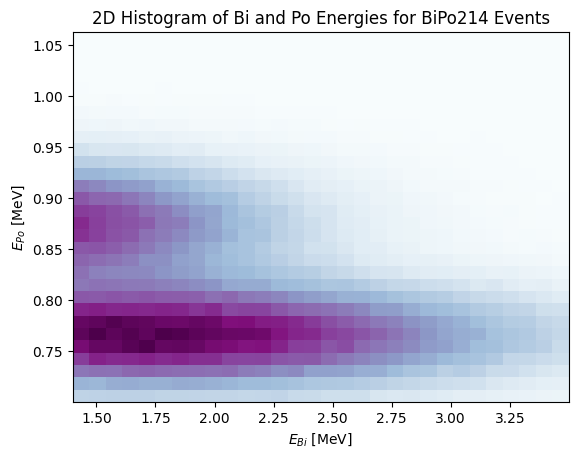

In [55]:
# Create the 2D histogram
plt.hist2d(energy_values_bi_214, energy_values_po_214, bins=(30, 30), cmap=plt.cm.BuPu)

# Label the axes
plt.xlabel("$E_{Bi}$ [MeV]")
plt.ylabel("$E_{Po}$ [MeV]")

# Add title
plt.title("2D Histogram of Bi and Po Energies for BiPo214 Events")

# Save the plot to a file
plt.savefig("../plots/classical_cuts/2d_hist_bipo214.png")

# Show the plot
plt.show()

In [31]:
time_diff_214 = calculate_time_differences_for_plot(bi_events_dc_214, po_events_dc_214)

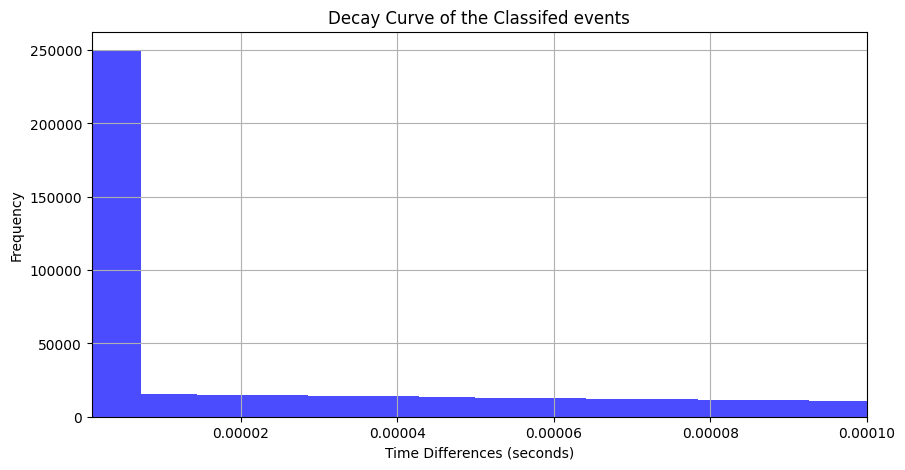

In [40]:
plot_histogram(time_diff_214, "Decay Curve of the Classifed events", "../plots/classical_cuts/decay_curve_214", "blue")

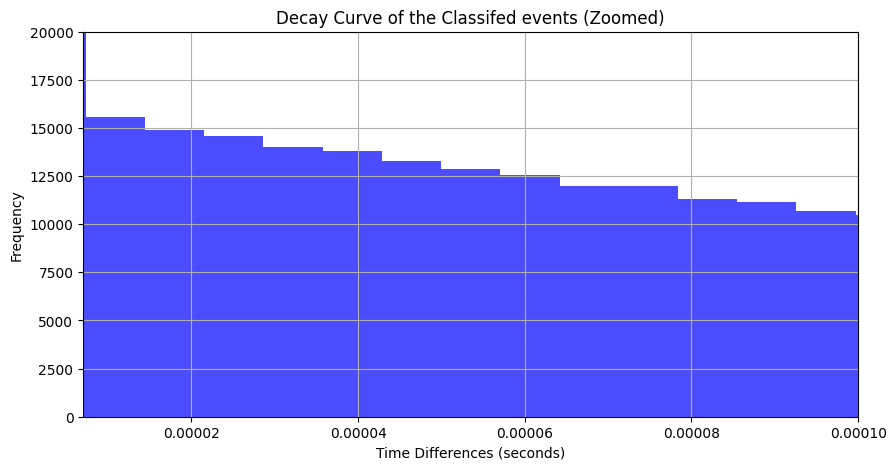

In [48]:
plot_histogram(time_diff_214, "Decay Curve of the Classifed events (Zoomed)", "../plots/classical_cuts/decay_curve_214_zoomed", "blue", x_limits=(0.000007, 0.00010), y_limits=(0, 20000) )

# Cuts for the 212 chain

In [49]:
#ENERGY CUT

# Define the energy ranges
bi_range_212 = (0.14, 2.5)
po_range_212 = (0.9, 1.5)

# Call the function with the event_data and energy ranges
bi_events_212, po_events_212 = energy_cut(event_data, bi_range_212, po_range_212)

In [50]:
len(po_events_212)

1177808

In [51]:
#FV CUT

# Define r_cut and z_cut values
r_cut = 1400
z_cut = 2000

# Apply fiducial volume cut to both Bi and Po events with custom r_cut and z_cut
bi_fv_212 = fv_cut(bi_events_212, r_cut, z_cut)
po_fv_212 = fv_cut(po_events_212, r_cut, z_cut)


In [52]:
len(bi_events_212)

5044259

In [53]:
#TIME CUT

# Define the time range
time_range_212 = (0.0000002, 0.000002)

# Apply time difference cut between bi_fv and po_fv
bi_events_tc_212, po_events_tc_212 = time_cut(bi_fv_212, po_fv_212, time_range_212)

In [56]:
#DISTANCE CUT

distance_range_212 = 725
bi_events_dc_212, po_events_dc_212 = distance_cut (bi_events_tc_212, po_events_tc_212, distance_range_212, time_range_212)

In [57]:
# Count occurrences of different MC values
count_MC(bi_events_dc_212)

Internal background: 0
214 Bi Events: 1
214 Po events: 0
External background: 0
212 Bi events: 154203
212 Po events: 0


In [58]:
energy_values_po_212 = [event.energy for event in po_events_dc_212]
energy_values_bi_212 = [event.energy for event in bi_events_dc_212]

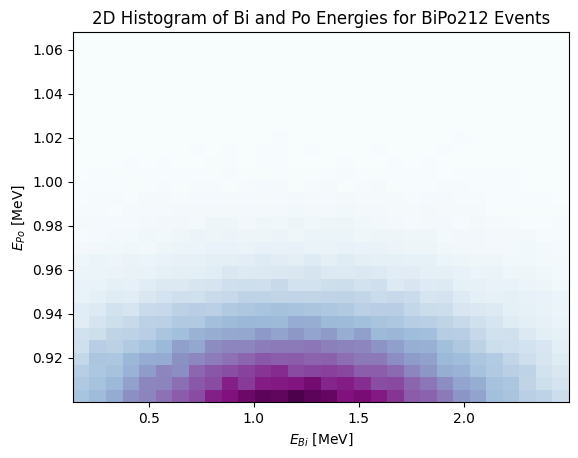

In [59]:
# Create the 2D histogram
plt.hist2d(energy_values_bi_212, energy_values_po_212, bins=(30, 30), cmap=plt.cm.BuPu)

# Label the axes
plt.xlabel("$E_{Bi}$ [MeV]")
plt.ylabel("$E_{Po}$ [MeV]")

# Add title
plt.title("2D Histogram of Bi and Po Energies for BiPo212 Events")

# Save the plot to a file
plt.savefig("../plots/classical_cuts/2d_hist_bipo212.png")

# Show the plot
plt.show()

In [ ]:
time_diff_212 = calculate_time_differences_for_plot(bi_events_dc_212, po_events_dc_212)

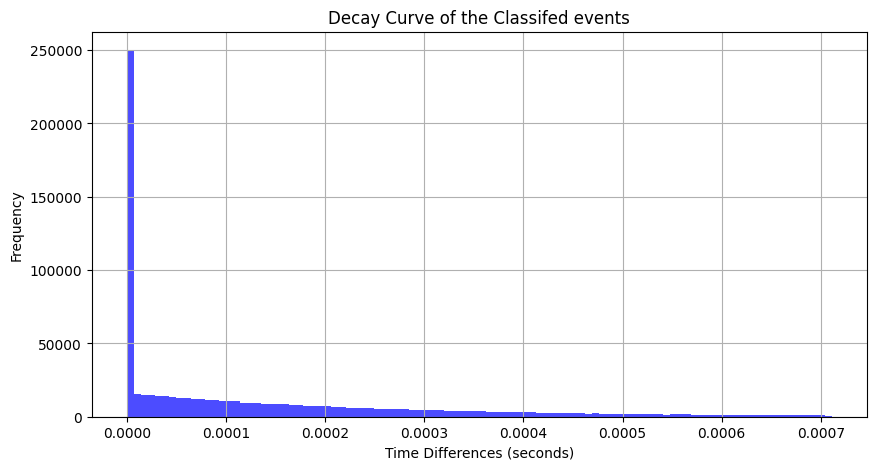

In [ ]:
plot_histogram(time_diff_212, "Decay Curve of the Classifed events", "../plots/classical_cuts/decay_curve_212", "blue")

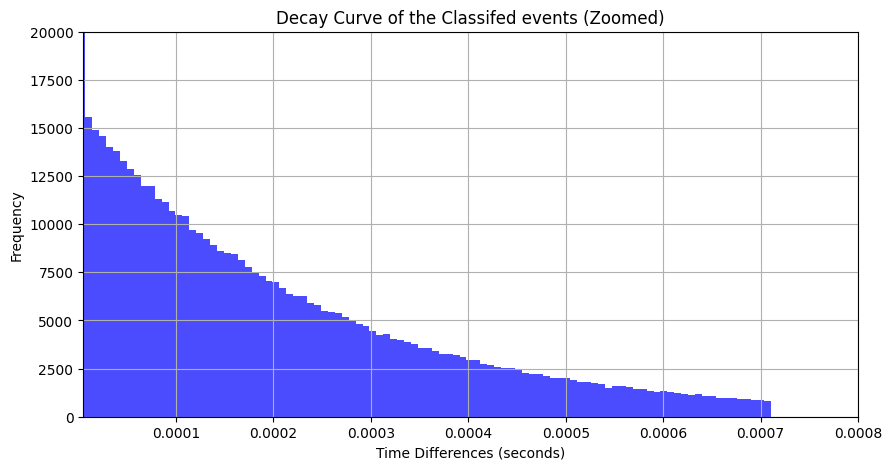

In [ ]:
plot_histogram(time_diff_212, "Decay Curve of the Classifed events (Zoomed)", "../plots/classical_cuts/decay_curve_212_zoomed", "blue", x_limits=(0.000005, 0.0008), y_limits=(0, 20000) )

In [69]:
calculate_metrics(event_data, bi_events_dc_214, po_events_dc_214, bi_events_dc_212, po_events_dc_212)

KeyboardInterrupt: 

New Cuts for 214 chain

In [28]:
#ENERGY CUT

# Define the energy ranges
bi_range_214 = (0.449, 4.597)
po_range_214 = (0.5, 1.025)

# Call the function with the event_data and energy ranges
bi_events_214, po_events_214 = energy_cut(event_data, bi_range_214, po_range_214)
po_events_length = len(po_events_214)
print("Number of Po events:", po_events_length)

Number of Po events: 1120173


In [29]:
#FV CUT

# Define r_cut and z_cut values
r_cut = 1143.651
z_cut = 1220.122

# Apply fiducial volume cut to both Bi and Po events with custom r_cut and z_cut
bi_fv_214 = fv_cut(bi_events_214, r_cut, z_cut)
po_fv_214 = fv_cut(po_events_214, r_cut, z_cut)

In [30]:
#TIME CUT

# Define the time range
time_range_214 = (0.0000002, 0.001436)

# Apply time difference cut between bi_fv and po_fv
bi_events_tc_214, po_events_tc_214 = time_cut(bi_fv_214, po_fv_214, time_range_214)

In [31]:
len(po_events_tc_214)

1596

In [32]:
#DISTANCE CUT

distance_range_214 = 498.382
bi_events_dc_214, po_events_dc_214 = distance_cut (bi_events_tc_214, po_events_tc_214, distance_range_214, time_range_214)

In [33]:
len(bi_events_dc_214)

1580

In [34]:
# Count occurrences of different MC values
count_MC(po_events_dc_214)

Internal background: 0
214 Bi Events: 0
214 Po events: 1300
External background: 0
212 Bi events: 0
212 Po events: 280


In [35]:
energy_values_po_214 = [event.energy for event in po_events_dc_214]
energy_values_bi_214 = [event.energy for event in bi_events_dc_214]


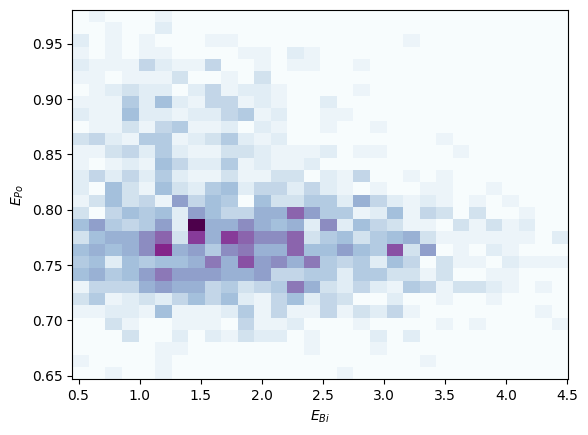

In [ ]:
# Create the 2D histogram
plt.hist2d(energy_values_bi_214, energy_values_po_214, bins=(30, 30), cmap=plt.cm.BuPu)

# Label the axes
plt.xlabel("$E_{Bi}$ [MeV]")
plt.ylabel("$E_{Po}$ [MeV]")

# Add title
plt.title("2D Histogram of Bi and Po Energies for BiPo214 Events")

# Save the plot to a file
plt.savefig("../plots/classical_cuts/2d_hist_bipo214_optcuts.png")

# Show the plot
plt.show()

In [ ]:
time_diff_214 = calculate_time_differences_for_plot(bi_events_dc_214, po_events_dc_214)

In [ ]:
plot_histogram(time_diff_214, "Decay Curve of the Classifed events", "../plots/classical_cuts/decay_curve_214_optcuts", "blue")

In [ ]:
plot_histogram(time_diff_214, "Decay Curve of the Classifed events (Zoomed)", "../plots/classical_cuts/decay_curve_214_zoomed_optcuts", "blue", x_limits=(0.000007, 0.00010), y_limits=(0, 20000) )

Cuts for the 212 chain

In [37]:
#ENERGY CUT

# Define the energy ranges
bi_range_212 = (0.465, 2.985)
po_range_212 = (0.293, 0.975)

# Call the function with the event_data and energy ranges
bi_events_212, po_events_212 = energy_cut(event_data, bi_range_212, po_range_212)

In [38]:
len(po_events_212)

1452985

In [39]:
#FV CUT

# Define r_cut and z_cut values
r_cut = 1483.219
z_cut = 1422.041

# Apply fiducial volume cut to both Bi and Po events with custom r_cut and z_cut
bi_fv_212 = fv_cut(bi_events_212, r_cut, z_cut)
po_fv_212 = fv_cut(po_events_212, r_cut, z_cut)

In [40]:
len(bi_events_212)

5340527

In [41]:
#TIME CUT

# Define the time range
time_range_212 = (0.0000002, 0.00001501)

# Apply time difference cut between bi_fv and po_fv
bi_events_tc_212, po_events_tc_212 = time_cut(bi_fv_212, po_fv_212, time_range_212)

In [42]:
#DISTANCE CUT

distance_range_212 = 898.043
bi_events_dc_212, po_events_dc_212 = distance_cut (bi_events_tc_212, po_events_tc_212, distance_range_212, time_range_212)

In [43]:
# Count occurrences of different MC values
count_MC(bi_events_dc_212)

Internal background: 0
214 Bi Events: 107
214 Po events: 0
External background: 0
212 Bi events: 463
212 Po events: 0


In [44]:
energy_values_po_212 = [event.energy for event in po_events_dc_212]
energy_values_bi_212 = [event.energy for event in bi_events_dc_212]

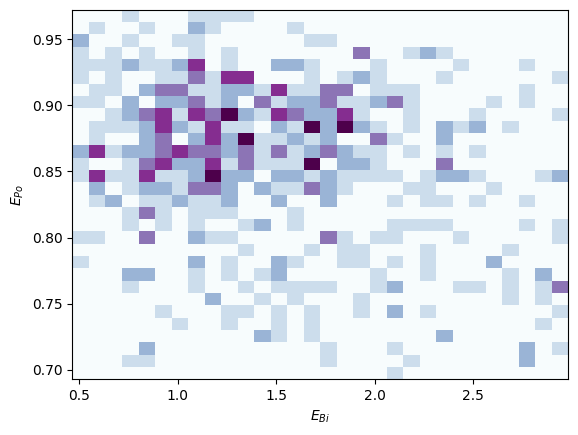

In [ ]:
# Create the 2D histogram
plt.hist2d(energy_values_bi_212, energy_values_po_212, bins=(30, 30), cmap=plt.cm.BuPu)

# Label the axes
plt.xlabel("$E_{Bi}$ [MeV]")
plt.ylabel("$E_{Po}$ [MeV]")

# Add title
plt.title("2D Histogram of Bi and Po Energies for BiPo212 Events")

# Save the plot to a file
plt.savefig("../plots/classical_cuts/2d_hist_bipo212_optcuts.png")

# Show the plot
plt.show()

In [ ]:
time_diff_212 = calculate_time_differences_for_plot(bi_events_dc_212, po_events_dc_212)

In [ ]:
plot_histogram(time_diff_212, "Decay Curve of the Classifed events", "../plots/classical_cuts/decay_curve_212_optcuts", "blue")

In [ ]:
plot_histogram(time_diff_212, "Decay Curve of the Classifed events (Zoomed)", "../plots/classical_cuts/decay_curve_212_zoomed_optcuts", "blue", x_limits=(0.000005, 0.0008), y_limits=(0, 20000) )

In [ ]:
calculate_metrics(event_data, bi_events_dc_214, po_events_dc_214, bi_events_dc_212, po_events_dc_212)